# Rational Fusion: ResNet50+Wavelet Hybrid  &times;  ResNet50V2+LightGBM
### Decision-level stacking, tuned for macro-F1 under class imbalance

This notebook fuses the two models you already trained:

| | Model A | Model B |
|---|---|---|
| Notebook | `ResNet50_Wavelet_Hybrid...` | `ResNet50V2_LightGBM...` |
| Backbone | ResNet50 (frozen, ImageNet) | ResNet50V2 (frozen, ImageNet) |
| Extra signal | Handcrafted DWT wavelet texture features | — |
| Classifier | Dense head, end-to-end trained | LightGBM (gradient-boosted trees) |
| Preprocessing | `resnet50.preprocess_input` (caffe-style) | `resnet_v2.preprocess_input` (tf-style, [-1,1]) |

**Why not just average the two softmax outputs 50/50 ("crude fusion")?**

1. The two models are **not equally reliable on every class**. Under class
   imbalance, one may dominate on the majority class and be weak on the
   minority class(es), while the other shows the opposite pattern. A fixed
   50/50 blend cannot exploit that.
2. The two probability vectors are **not calibrated on the same scale** — a
   dense softmax head and a boosted-tree softmax are optimized with
   different losses/regularization, so `0.7` from Model A does not mean the
   same thing as `0.7` from Model B.
3. Averaging **only helps if the models make different mistakes**. If their
   errors are highly correlated, fusion buys you nothing (and can hurt). We
   verify this empirically before trusting any fused model.

**What this notebook actually does (rational fusion):**

1. Re-extract validation/test predictions from both frozen models using an
   **identical, explicitly-ordered file list**, so probabilities line up
   sample-for-sample (a common silent bug when two separate generators are
   assumed to agree on order).
2. **Diagnose complementarity** on the validation set: per-class F1 for each
   model alone, disagreement rate, and the "A wrong / B right" vs "A right /
   B wrong" breakdown. This is the empirical justification for fusing at
   all.
3. Fit fusion parameters **only on validation data**, optimizing **macro-F1
   directly** (not accuracy, which is misleading under imbalance):
   - **Weighted probability averaging** — grid-search the blend weight
     &alpha; that maximizes validation macro-F1.
   - **Stacking meta-learner** — a class-weighted logistic regression on
     `[P_A | P_B]`, evaluated with stratified cross-validation on the
     validation set so we don't just overfit to it.
4. **Select** whichever fusion strategy generalizes best on the
   cross-validated validation score (guards against the meta-learner
   overfitting a small validation split).
5. **Evaluate once, on the held-out test set** — classification report,
   confusion matrix, and a side-by-side comparison table (Model A alone /
   Model B alone / Fused) so the improvement is actually verifiable, not
   assumed.

> Fusion is not guaranteed to beat both base models — it is guaranteed to be
> **no worse than the better strategy the validation data supports**, because
> step 4 explicitly measures and picks the best option instead of assuming
> fusion always wins.

In [19]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import json
import numpy as np
import cv2
import pywt
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, ResNet50V2
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_input_r50
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_input_r50v2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)

import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.10.0
Num GPUs Available: 1


In [20]:
# ==========================================================
# CONFIGURATION
# ==========================================================
DATASET_PATH = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Imbalanced"  # <-- same as both source notebooks

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32          # mini-batch size used only for feature/probability extraction (inference)

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2

# Path to the weights you saved when you ran the ResNet50+Wavelet notebook
MODEL_A_WEIGHTS_PATH = "ResNet50_Wavelet_Hybrid_Imbalanced_model.h5"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [21]:
# ==========================================================
# CANONICAL, EXPLICITLY-ORDERED FILE LISTS
# ==========================================================
# Both source notebooks build their own generator internally and just trust
# that "the order lines up". For fusion we need Model A's and Model B's
# predictions on the SAME sample in the SAME row, so we build one canonical,
# deterministically-sorted file list per split and drive *both* branches off
# of it explicitly. Class order is alphabetical (sorted class dirs), matching
# what flow_from_directory / the custom Sequence in both notebooks already do.

def build_file_list(directory):
    class_names = sorted(
        d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))
    )
    class_indices = {name: i for i, name in enumerate(class_names)}

    filepaths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                filepaths.append(os.path.join(cls_dir, fname))
                labels.append(class_indices[cls])

    return filepaths, np.array(labels, dtype=np.int64), class_names


train_files, y_train, class_names = build_file_list(train_dir)
val_files, y_val, class_names_val = build_file_list(val_dir)
test_files, y_test, class_names_test = build_file_list(test_dir)

assert class_names == class_names_val == class_names_test, "Class ordering mismatch across splits!"
print("Classes:", class_names)
print("Train / Val / Test sizes:", len(train_files), len(val_files), len(test_files))


Classes: ['Benign', 'Malignant', 'Normal']
Train / Val / Test sizes: 13787 2942 3002


In [22]:
# ==========================================================
# WAVELET FEATURE EXTRACTION (identical to the ResNet50+Wavelet notebook)
# ==========================================================
def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)

    features = []
    for idx, c in enumerate(coeffs):
        sub_bands = [c] if idx == 0 else list(c)
        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)

    return np.array(features, dtype=np.float32)


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Wavelet feature vector length: {WAVELET_FEATURE_DIM}")


Wavelet feature vector length: 21


In [23]:
# ==========================================================
# REBUILD MODEL A (ResNet50 + Wavelet hybrid) AND LOAD TRAINED WEIGHTS
# ==========================================================
def get_ResNet50_Wavelet_Hybrid():
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(input_tensor=image_input, weights='imagenet', include_top=False)
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(0.3)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu')(x_wav)
    x_wav = Dropout(0.3)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu')(fused)
    fused = Dropout(0.3)(fused)
    output = Dense(NUM_CLASSES, activation='softmax')(fused)

    return Model(inputs=[image_input, wavelet_input], outputs=output)


model_a = get_ResNet50_Wavelet_Hybrid()
model_a.load_weights(MODEL_A_WEIGHTS_PATH)
print("Model A (ResNet50 + Wavelet) weights loaded.")


Model A (ResNet50 + Wavelet) weights loaded.


In [24]:
# ==========================================================
# REBUILD MODEL B'S BACKBONE (ResNet50V2 feature extractor) AND TRAIN LIGHTGBM
# ==========================================================
# The original notebook never persisted the trained LightGBM booster to disk,
# so it is retrained here on features extracted with the same canonical file
# lists above -- this guarantees train/val alignment and is cheap, since only
# a frozen backbone forward pass + tree boosting is involved (no CNN training).

base_model_b = ResNet50V2(input_shape=MODEL_INPUT_SIZE, weights='imagenet', include_top=False)
base_model_b.trainable = False
feature_extractor_b = Model(inputs=base_model_b.input,
                             outputs=GlobalAveragePooling2D()(base_model_b.output))


def extract_backbone_features(filepaths, preprocess_fn, batch_size=64):
    # Runs a frozen backbone over a file list and returns an (N, feat_dim) array.
    n = len(filepaths)
    feats = None
    for start in range(0, n, batch_size):
        batch_fps = filepaths[start:start + batch_size]
        imgs = np.zeros((len(batch_fps), *IMAGE_SIZE, 3), dtype=np.float32)
        for i, fp in enumerate(batch_fps):
            img_bgr = cv2.imread(fp)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, IMAGE_SIZE)
            imgs[i] = img_rgb.astype(np.float32)
        imgs = preprocess_fn(imgs)
        batch_feats = feature_extractor_b.predict(imgs, verbose=0)
        if feats is None:
            feats = np.zeros((n, batch_feats.shape[1]), dtype=np.float32)
        feats[start:start + len(batch_fps)] = batch_feats
    return feats


print("Extracting ResNet50V2 features for LightGBM training set...")
X_train_feat = extract_backbone_features(train_files, preprocess_input_r50v2)

print("Extracting ResNet50V2 features for LightGBM validation set...")
X_val_feat = extract_backbone_features(val_files, preprocess_input_r50v2)

lgb_params = {
    "objective": "multiclass",
    "num_class": NUM_CLASSES,
    "metric": "multi_logloss",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

train_data = lgb.Dataset(X_train_feat, label=y_train)
val_data = lgb.Dataset(X_val_feat, label=y_val, reference=train_data)

model_b = lgb.train(
    lgb_params, train_data, num_boost_round=5000,
    valid_sets=[train_data, val_data], valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=300), lgb.log_evaluation(period=50)],
)

# Persist it this time, so future runs don't need to retrain it
model_b.save_model("ResNet50V2_LightGBM_Imbalanced_model.txt")
print("Model B (ResNet50V2 + LightGBM) trained and saved.")


Extracting ResNet50V2 features for LightGBM training set...
Extracting ResNet50V2 features for LightGBM validation set...
Training until validation scores don't improve for 300 rounds
[50]	train's multi_logloss: 0.714558	val's multi_logloss: 0.78424
[100]	train's multi_logloss: 0.572876	val's multi_logloss: 0.714028
[150]	train's multi_logloss: 0.479196	val's multi_logloss: 0.683118
[200]	train's multi_logloss: 0.408373	val's multi_logloss: 0.666375
[250]	train's multi_logloss: 0.351103	val's multi_logloss: 0.654809
[300]	train's multi_logloss: 0.303743	val's multi_logloss: 0.647868
[350]	train's multi_logloss: 0.264231	val's multi_logloss: 0.643886
[400]	train's multi_logloss: 0.230121	val's multi_logloss: 0.638913
[450]	train's multi_logloss: 0.201446	val's multi_logloss: 0.63615
[500]	train's multi_logloss: 0.17641	val's multi_logloss: 0.635399
[550]	train's multi_logloss: 0.154886	val's multi_logloss: 0.63478
[600]	train's multi_logloss: 0.136394	val's multi_logloss: 0.633379
[650]

In [25]:
# ==========================================================
# ALIGNED PROBABILITY EXTRACTION FOR BOTH MODELS, ON A GIVEN FILE LIST
# ==========================================================
def get_model_probabilities(filepaths, batch_size=BATCH_SIZE):
    n = len(filepaths)
    probs_a = np.zeros((n, NUM_CLASSES), dtype=np.float32)
    probs_b = np.zeros((n, NUM_CLASSES), dtype=np.float32)

    for start in range(0, n, batch_size):
        batch_fps = filepaths[start:start + batch_size]
        raw = np.zeros((len(batch_fps), *IMAGE_SIZE, 3), dtype=np.float32)
        for i, fp in enumerate(batch_fps):
            img_bgr = cv2.imread(fp)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, IMAGE_SIZE)
            raw[i] = img_rgb.astype(np.float32)

        # ---- Model A: ResNet50 (caffe preprocessing) + wavelet branch ----
        wavelet_batch = np.stack([extract_wavelet_features(im) for im in raw])
        resnet50_batch = preprocess_input_r50(raw.copy())
        probs_a[start:start + len(batch_fps)] = model_a.predict(
            [resnet50_batch, wavelet_batch], verbose=0
        )

        # ---- Model B: ResNet50V2 (tf preprocessing) features -> LightGBM ----
        resnet50v2_batch = preprocess_input_r50v2(raw.copy())
        feats_b = feature_extractor_b.predict(resnet50v2_batch, verbose=0)
        probs_b[start:start + len(batch_fps)] = model_b.predict(
            feats_b, num_iteration=model_b.best_iteration
        )

    return probs_a, probs_b


print("Extracting aligned probabilities on the validation set...")
probs_a_val, probs_b_val = get_model_probabilities(val_files)

print("Extracting aligned probabilities on the test set...")
probs_a_test, probs_b_test = get_model_probabilities(test_files)


Extracting aligned probabilities on the validation set...
Extracting aligned probabilities on the test set...


In [26]:
# ==========================================================
# STEP 1 — DIAGNOSE COMPLEMENTARITY (validation set only)
# ==========================================================
# Fusion is only worth doing if the two models actually disagree, and
# disagree in ways where one is right when the other is wrong. This is the
# empirical check before we trust any fusion result.

preds_a_val = np.argmax(probs_a_val, axis=1)
preds_b_val = np.argmax(probs_b_val, axis=1)

f1_a_per_class = f1_score(y_val, preds_a_val, average=None)
f1_b_per_class = f1_score(y_val, preds_b_val, average=None)

print("Per-class F1 (validation set)")
print(f"{'Class':<15}{'Model A':>10}{'Model B':>10}")
for cname, fa, fb in zip(class_names, f1_a_per_class, f1_b_per_class):
    print(f"{cname:<15}{fa:>10.3f}{fb:>10.3f}")

disagree_mask = preds_a_val != preds_b_val
disagree_rate = disagree_mask.mean()

a_right_b_wrong = np.mean((preds_a_val == y_val) & (preds_b_val != y_val))
b_right_a_wrong = np.mean((preds_b_val == y_val) & (preds_a_val != y_val))
both_wrong = np.mean((preds_a_val != y_val) & (preds_b_val != y_val))
both_right = np.mean((preds_a_val == y_val) & (preds_b_val == y_val))

print(f"\nDisagreement rate (A vs B predictions): {disagree_rate*100:.1f}%")
print(f"A right, B wrong : {a_right_b_wrong*100:.1f}%  <- fusion can recover these via B's confidence in A")
print(f"B right, A wrong : {b_right_a_wrong*100:.1f}%  <- fusion can recover these via A's confidence in B")
print(f"Both wrong        : {both_wrong*100:.1f}%  <- fusion cannot fix these")
print(f"Both right        : {both_right*100:.1f}%")

if (a_right_b_wrong + b_right_a_wrong) < 0.02:
    print("\n[WARNING] The models rarely disagree on cases where only one is correct. "
          "Fusion is unlikely to meaningfully move macro-F1 -- double check preprocessing/"
          "alignment before trusting the fused result below.")


Per-class F1 (validation set)
Class             Model A   Model B
Benign              0.648     0.587
Malignant           0.778     0.747
Normal              0.848     0.777

Disagreement rate (A vs B predictions): 19.6%
A right, B wrong : 10.7%  <- fusion can recover these via B's confidence in A
B right, A wrong : 5.7%  <- fusion can recover these via A's confidence in B
Both wrong        : 18.5%  <- fusion cannot fix these
Both right        : 65.1%


In [27]:
# ==========================================================
# STEP 2a — WEIGHTED PROBABILITY AVERAGING, TUNED FOR MACRO-F1
# ==========================================================
# fused_probs = alpha * P_A + (1 - alpha) * P_B
# alpha is *searched*, not assumed to be 0.5 ("crude" fusion), and is chosen
# to directly maximize the metric we actually care about (macro-F1), not
# accuracy, which is dominated by the majority class under imbalance.

alphas = np.linspace(0.0, 1.0, 101)
best_alpha, best_alpha_f1 = None, -1.0

for a in alphas:
    fused = a * probs_a_val + (1 - a) * probs_b_val
    preds = np.argmax(fused, axis=1)
    f1 = f1_score(y_val, preds, average='macro')
    if f1 > best_alpha_f1:
        best_alpha_f1, best_alpha = f1, a

f1_a_val_macro = f1_score(y_val, preds_a_val, average='macro')
f1_b_val_macro = f1_score(y_val, preds_b_val, average='macro')

print(f"Model A alone   -- val macro-F1: {f1_a_val_macro:.4f}")
print(f"Model B alone   -- val macro-F1: {f1_b_val_macro:.4f}")
print(f"Best alpha      : {best_alpha:.2f}  (weight on Model A)")
print(f"Weighted-avg fusion -- val macro-F1: {best_alpha_f1:.4f}")


Model A alone   -- val macro-F1: 0.7579
Model B alone   -- val macro-F1: 0.7036
Best alpha      : 0.86  (weight on Model A)
Weighted-avg fusion -- val macro-F1: 0.7580


In [28]:
# ==========================================================
# STEP 2b — STACKING META-LEARNER (logistic regression on [P_A | P_B])
# ==========================================================
# A meta-learner can weight each model differently *per class*, which a
# single scalar alpha cannot. class_weight='balanced' keeps it from ignoring
# the minority class. We estimate its generalization with stratified CV on
# the validation set (rather than just fitting+scoring on the same data),
# since the validation split may be small relative to a learned model.

stack_features_val = np.hstack([probs_a_val, probs_b_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
meta_clf_cv = LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='multinomial')
cv_scores = cross_val_score(meta_clf_cv, stack_features_val, y_val, cv=skf, scoring='f1_macro')

stacking_cv_f1 = cv_scores.mean()
print(f"Stacking meta-learner -- {5}-fold CV macro-F1 on validation set: "
      f"{stacking_cv_f1:.4f} (+/- {cv_scores.std():.4f})")

# Refit on the full validation set for deployment, now that CV has told us
# how well it's expected to generalize.
meta_clf = LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='multinomial')
meta_clf.fit(stack_features_val, y_val)


Stacking meta-learner -- 5-fold CV macro-F1 on validation set: 0.7608 (+/- 0.0160)


C:\ProgramData\anaconda3\envs\tf_gpu_210\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\envs\tf_gpu_210\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\envs\tf_gpu_210\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\envs\tf_gpu_210\lib\site-packages\sklearn\linear_model\_logisti

LogisticRegression(class_weight='balanced', max_iter=2000,
                   multi_class='multinomial')

In [29]:
# ==========================================================
# STEP 3 — SELECT THE BEST FUSION STRATEGY (validation evidence only)
# ==========================================================
candidates = {
    "model_a_alone": f1_a_val_macro,
    "model_b_alone": f1_b_val_macro,
    "weighted_average": best_alpha_f1,
    "stacking_meta_learner": stacking_cv_f1,   # cross-validated, not optimistic in-sample score
}

for name, score in sorted(candidates.items(), key=lambda kv: -kv[1]):
    print(f"{name:<24}: val macro-F1 = {score:.4f}")

fusion_strategy = max(candidates, key=candidates.get)
print(f"\nSelected strategy: {fusion_strategy}")


stacking_meta_learner   : val macro-F1 = 0.7608
weighted_average        : val macro-F1 = 0.7580
model_a_alone           : val macro-F1 = 0.7579
model_b_alone           : val macro-F1 = 0.7036

Selected strategy: stacking_meta_learner


In [30]:
# ==========================================================
# STEP 4 — FINAL, ONE-TIME EVALUATION ON THE TEST SET
# ==========================================================
preds_a_test = np.argmax(probs_a_test, axis=1)
preds_b_test = np.argmax(probs_b_test, axis=1)

if fusion_strategy == "weighted_average":
    fused_probs_test = best_alpha * probs_a_test + (1 - best_alpha) * probs_b_test
    preds_fused_test = np.argmax(fused_probs_test, axis=1)
elif fusion_strategy == "stacking_meta_learner":
    stack_features_test = np.hstack([probs_a_test, probs_b_test])
    preds_fused_test = meta_clf.predict(stack_features_test)
elif fusion_strategy == "model_a_alone":
    preds_fused_test = preds_a_test
else:
    preds_fused_test = preds_b_test

f1_a_test = f1_score(y_test, preds_a_test, average='macro')
f1_b_test = f1_score(y_test, preds_b_test, average='macro')
f1_fused_test = f1_score(y_test, preds_fused_test, average='macro')

print("="*50)
print("TEST SET -- MACRO-F1 COMPARISON")
print("="*50)
print(f"Model A alone (ResNet50+Wavelet)  : {f1_a_test:.4f}")
print(f"Model B alone (ResNet50V2+LGBM)   : {f1_b_test:.4f}")
print(f"Fused ({fusion_strategy:<20}): {f1_fused_test:.4f}")

print("\nClassification report -- FUSED MODEL (test set):\n")
print(classification_report(y_test, preds_fused_test, target_names=class_names))


TEST SET -- MACRO-F1 COMPARISON
Model A alone (ResNet50+Wavelet)  : 0.7245
Model B alone (ResNet50V2+LGBM)   : 0.6847
Fused (stacking_meta_learner): 0.7257

Classification report -- FUSED MODEL (test set):

              precision    recall  f1-score   support

      Benign       0.60      0.61      0.61       924
   Malignant       0.75      0.71      0.73      1309
      Normal       0.81      0.87      0.84       769

    accuracy                           0.72      3002
   macro avg       0.72      0.73      0.73      3002
weighted avg       0.72      0.72      0.72      3002



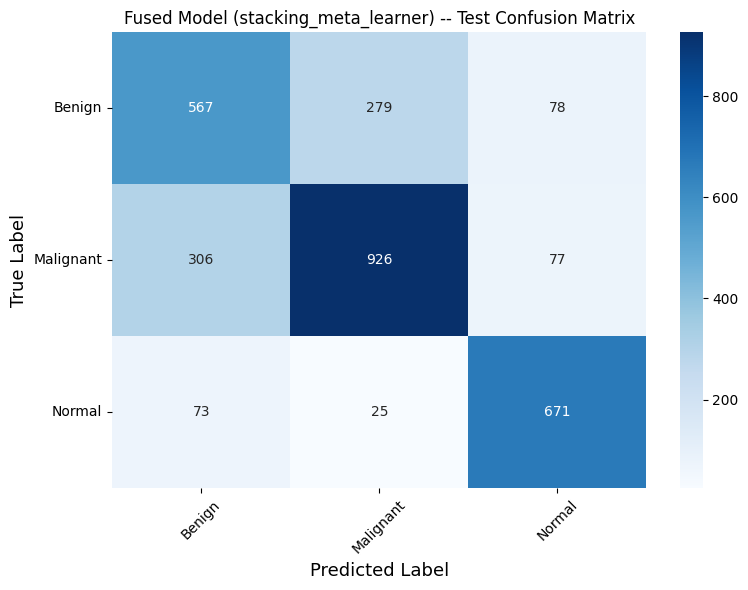

In [31]:
# ==========================================================
# CONFUSION MATRIX -- FUSED MODEL (test set)
# ==========================================================
cm = confusion_matrix(y_test, preds_fused_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.title(f"Fused Model ({fusion_strategy}) -- Test Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Fused_Model_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [32]:
# ==========================================================
# SAVE FUSION ARTIFACTS + SINGLE-IMAGE INFERENCE FUNCTION
# ==========================================================
fusion_config = {
    "strategy": fusion_strategy,
    "alpha_weight_on_model_a": float(best_alpha) if fusion_strategy == "weighted_average" else None,
    "class_names": class_names,
}
with open("fusion_config.json", "w") as f:
    json.dump(fusion_config, f, indent=2)

if fusion_strategy == "stacking_meta_learner":
    joblib.dump(meta_clf, "fusion_meta_learner.joblib")

print("Saved fusion_config.json"
      + (" and fusion_meta_learner.joblib" if fusion_strategy == "stacking_meta_learner" else ""))


def predict_fused(image_path):
    # Run both frozen models on a single image and return the fused prediction.
    probs_a, probs_b = get_model_probabilities([image_path], batch_size=1)

    if fusion_strategy == "weighted_average":
        fused = best_alpha * probs_a + (1 - best_alpha) * probs_b
    elif fusion_strategy == "stacking_meta_learner":
        fused = meta_clf.predict_proba(np.hstack([probs_a, probs_b]))
    elif fusion_strategy == "model_a_alone":
        fused = probs_a
    else:
        fused = probs_b

    pred_idx = int(np.argmax(fused, axis=1)[0])
    return {
        "predicted_class": class_names[pred_idx],
        "probabilities": dict(zip(class_names, fused[0].tolist())),
    }


# Example:
# print(predict_fused(test_files[0]))


Saved fusion_config.json and fusion_meta_learner.joblib
